In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymultinest
from getdist import plots, MCSamples

## MOPED compression special case

We have two data blocks.

- `A` = cosmic-shear, dim=`pA`
- `B` = map3, dim=`pB`

`A` and `B` correlates and have cross-covariance.
We can estimate full covariane from `N` sims.
We have analytic covariance for `A`. 

Our problem is `pB` < `pA` ~ `N`.

### Possible solution
Estimate compression matrix for `A` from analytic covariance. Test the compression by comparing the posterior with analytic covariance vs the posterior with compressed dv (where we use analytic covariance for compression, but use simulation-based covariance for inference)

In [2]:
def model(params, base=None):
    if base is None:
        base = np.linspace(0, 5, p)
    # Example: 4 param model
    # out  = params[0]*np.exp(-params[1]*base) * (1+params[2]*np.exp(-(base-params[3])**2)/3)
    # Example: 3 param model
    out = params[0] * np.exp(-params[1]*base) + params[2]*np.exp(-(base-2.5)**2/2/0.3**2)
    return out

In [3]:
def compute_moped_matrix(ic, params, dp=0.01, sel=None):
    # dim os params
    m = len(params)

    if sel is None:
        sel = np.ones(p, dtype=bool)
    psub= np.sum(sel)

    print('Compressing {} -> {}'.format(psub, m))

    derivatives = np.zeros((m, psub))
    for i in range(m):
        # plus
        pp = params.copy()
        pp[i] *= 1+dp
        k_plus = model(pp)[sel]
        # plus 2
        pp2 = params.copy()
        pp2[i] *= 1+2*dp
        k_plus2 = model(pp2)[sel]
        # minus
        pm = params.copy()
        pm[i] *= 1-dp
        k_minus = model(pm)[sel]
        # minus 2
        pm2 = params.copy()
        pm2[i] *= 1-2*dp
        k_minus2 = model(pm2)[sel]
        # derivative
        h = params[i] * dp
        d = (-k_plus2 + 8*k_plus - 8*k_minus + k_minus2) / 12/h
        # assign
        derivatives[i] = d

    # compute the moped matrix
    c = np.linalg.inv(ic[np.ix_(sel, sel)])
    b = np.zeros((m,psub))
    for i in range(m):
        mum_bq = np.einsum('i,qi->q', derivatives[i], b)
        bm = np.dot(ic[np.ix_(sel, sel)], derivatives[i])
        bm-= np.einsum('q,qi->i', mum_bq, b)
        bm/= np.abs(np.einsum('i,ij,j->', bm, c, bm))**0.5
        # update matrix
        b[i,:] = bm

    # set identity matrix for uncompressed data vectors
    m2 = p-psub # length of uncompressed DV
    b_full = np.zeros((m+m2,p))
    b_full[:m, sel] = b
    b_full[m:,~sel] = np.eye(m2)

    return b_full

In [4]:
def lnpost(data, params, ic, b=None, boundary=None):
    theo = model(params)
    if b is not None:
        data = np.dot(b, data)
        theo = np.dot(b, theo)
        c = np.linalg.inv(ic)
        c = np.dot(b, np.dot(c, b.T))
        ic= np.linalg.inv(c)
    diff = data - theo
    chi2 = np.dot(diff, np.dot(ic, diff))
    out = -0.5*chi2

    if boundary is not None:
        for i in range(len(params)):
            if params[i] < boundary[i][0] or params[i] > boundary[i][1]:
                out = -np.inf
    return out

def sample_param(data, ic, params, b=None, nwalkers=10, boundary=None, f_hartlap=1):
    # def temporary_lnpost(params):
    #     return lnpost(data, params, ic, b, boundary) * f_hartlap
    # ndim = len(params)
    # pos = [params + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    # sampler = emcee.EnsembleSampler(nwalkers, ndim, temporary_lnpost)
    # sampler.run_mcmc(pos, 2000)
    # samples = sampler.get_chain(discard=100, thin=15, flat=True)
    # return samples

    def lnpost_temp(cube, ndim, nparams):
        params = cube
        return lnpost(data, params, ic, b) * f_hartlap

    def prior_temp(cube, ndim, nparams):
        for i in range(ndim):
            cube[i] = cube[i] * (boundary[i][1] - boundary[i][0]) + boundary[i][0]
    
    n_params = len(params)
    pymultinest.run(lnpost_temp, prior_temp, n_params, outputfiles_basename='../output/moped-toy/temp', resume=False, verbose=False, n_live_points=200)

    samples = np.loadtxt('../output/moped-toy/temp.txt')
    weight = samples[:,0]
    samples = samples[:,2:]

    print(f_hartlap)
    return samples, weight

#### Noiseless data case

In [5]:
rng = np.random.default_rng(0)

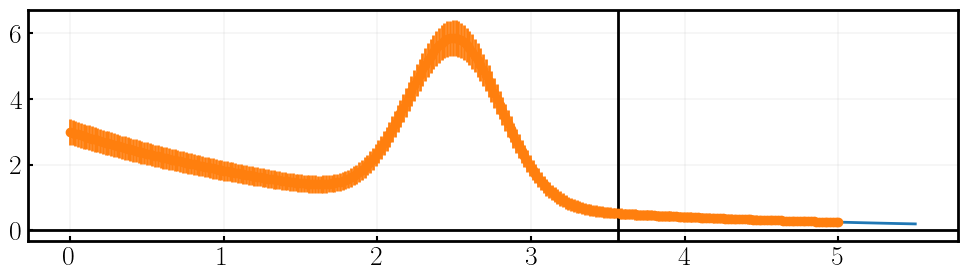

In [14]:
# problem setup
# p = 28
# N = 40
# pA= 20
p = 280
N = 400
pA = 200
pB= p-pA

# data
params = [3, 0.5, 5]
data = model(params)

# true covariance
c = np.diag(data*0.05)
ic= np.linalg.inv(c)

# sim cov
x = rng.multivariate_normal(np.zeros(p), c, N)
c_est = np.cov(x.T)
ic_est= np.linalg.inv(c_est)

plt.figure(figsize=(12, 3))
# plt.yscale('log')
plt.axhline(0.0, color='k')
plt.grid()
_ = np.linspace(0, 5.5, 100)
plt.plot(_, model(params, _), label='Model')
plt.errorbar(np.linspace(0,5,p), data, yerr=np.diag(c)**0.5, label='Data', fmt='.')
plt.axvline(np.linspace(0,5,p)[:pA].max(), color='k')
plt.show()

In [15]:
names = ['a', 'b', 'c']
boundary = [[0, 5], [0, 2], [0, 10]]

# 1. with true covariance
%time samples, w = sample_param(data, ic, params, boundary=boundary)
mcs = MCSamples(samples=samples, names=names, label='True', weights=w)
print('True', samples.shape)

# 2. with estimated covariance
%time samples, w = sample_param(data, ic_est, params, boundary=boundary, f_hartlap=(N-p-2)/(N-1))
mcs_est = MCSamples(samples=samples, names=names, label=f'Cov from {N} sims', weights=w)
print('Estimated', samples.shape)

# 3. moped compression
b = compute_moped_matrix(ic_est, params)
%time samples, w = sample_param(data, ic_est, params, b=b, boundary=boundary, f_hartlap=(N-len(params)-2)/(N-1))
mcs_moped = MCSamples(samples=samples, names=names, label=f'MOPED', weights=w)
print('MOPED', samples.shape)

# 3. partial moped compression
sel = np.ones(p, dtype=bool); sel[pA:] = False
b = compute_moped_matrix(ic, params, sel=sel)
%time samples, w = sample_param(data, ic_est, params, b=b, boundary=boundary, f_hartlap=(N-len(params)-pB-2)/(N-1))
mcs_moped_part = MCSamples(samples=samples, names=names, label=f'MOPED part', weights=w)
print('MOPED', samples.shape)

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -11.619475552996969      +/-  0.22553895127570428     
 Total Likelihood Evaluations:         4278
 Sampling finished. Exiting MultiNest
1
CPU times: user 711 ms, sys: 83.6 ms, total: 795 ms
Wall time: 976 ms
Removed no burn in
True (1998, 3)
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -11.779220192377062      +/-  0.22605625035621230     
 Total Likelihood Evaluations:         3678
 Sampling finished. Exiting MultiNest
0.2957393483709273
CPU times: user 835 ms, sys: 76.2 ms, total: 912 ms
Wall time: 924 ms
Removed no burn in
Estimated (1974, 3)
Comp

Text(0.5, 1.02, 'data dimension = 280')

<Figure size 600x600 with 0 Axes>

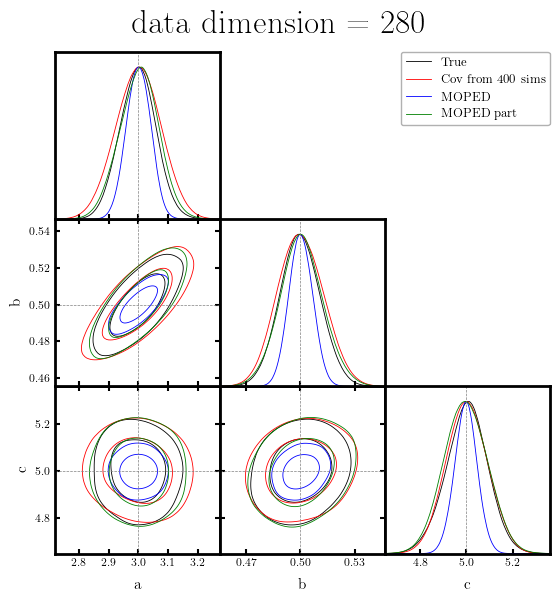

In [16]:
g = plots.get_single_plotter(ratio=1)
g.triangle_plot([mcs, mcs_est, mcs_moped, mcs_moped_part], markers=params, fill=False)
plt.suptitle(f'data dimension = {p}', y=1.02)

## noisy case
Here we test the MOPED compression works even on noisy data.

We worry about the scenario where the simuation-based covariance mistakenly underestimate the variance of a specific data vector element due to small number of realization, and the MOPED mistakenly upweight the data vector element that has larger noise than estimated, then it would be possible that the compressed data vector is **not** robust against the noise realization.

*Possible counter argument*: as long as the compressed covariance is accurate, this mistake in choosing the noisy element of the uncompressed data vector could be taken into account by the compressed covariance.

In [70]:
%%time
# noise realizations by true covariance
ns = rng.multivariate_normal(np.zeros(p), c, 15)

mcs_n = []
mcs_moped_n = []
for i, n in enumerate(ns):
    data = model(params) + n
    # true
    samples, w = sample_param(data, ic, params, boundary=boundary)
    _ = MCSamples(samples=samples, names=names, label=f'True n{i}', weights=w)
    mcs_n.append(_)
    # moped
    samples, w = sample_param(data, ic, params, b=b, boundary=boundary, f_hartlap=(N-len(params)-2)/(N-1))
    _ = MCSamples(samples=samples, names=names, label=f'MOPED n{i}', weights=w)
    mcs_moped_n.append(_)

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -14.616530015835879      +/-  0.16700143686465632     
 Total Likelihood Evaluations:         2478
 Sampling finished. Exiting MultiNest
1
Removed no burn in
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -5.9295731859248857      +/-  0.14377573428816373     
 Total Likelihood Evaluations:         2307
 Sampling finished. Exiting MultiNest
0.8620689655172413
Removed no burn in
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3


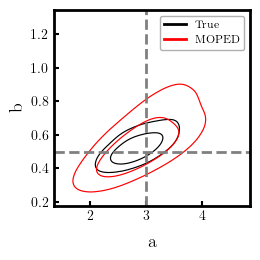

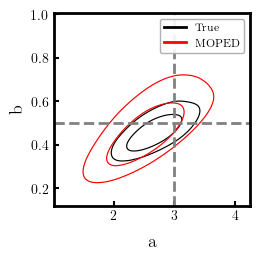

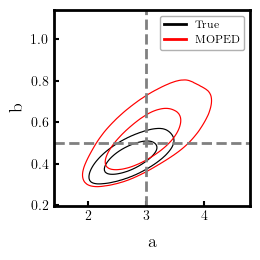

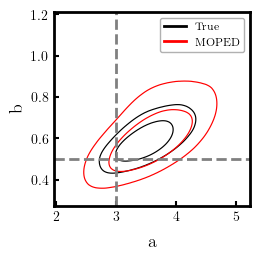

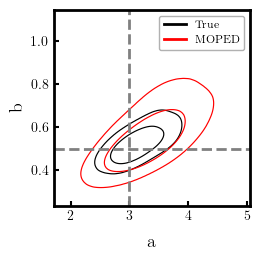

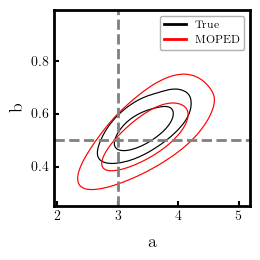

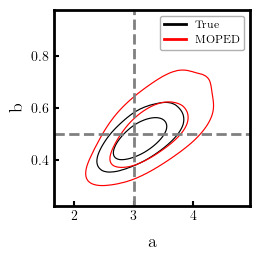

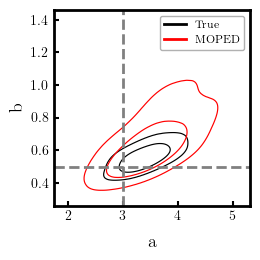

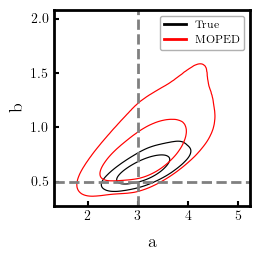

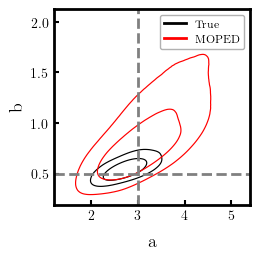

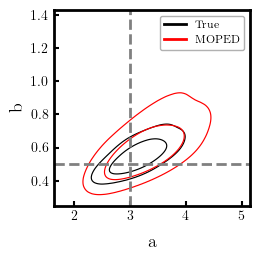

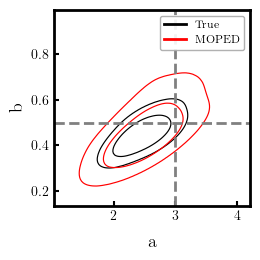

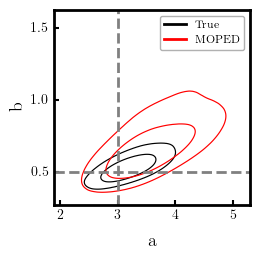

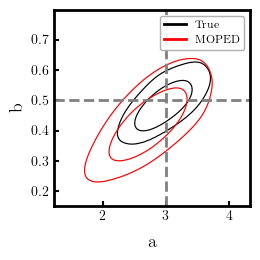

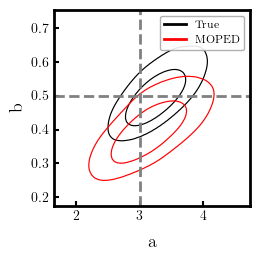

In [71]:
for i in range(len(mcs_moped_n)):
    g = plots.get_single_plotter(ratio=1, width_inch=3)
    g.plot_2d([mcs_n[i], mcs_moped_n[i]], 'a', 'b', filled=False, contour_colors=['k', 'red'])
    ax = g.subplots[0,0]
    ax.axhline(params[1], color='gray', ls='--')
    ax.axvline(params[0], color='gray', ls='--')
    ax.plot(np.nan, color='k', label='True')
    ax.plot(np.nan, color='red', label='MOPED')
    ax.legend(fontsize=8)
    plt.show()